# PCA From Scratch -- Iris Dataset

### 1. Import libraries 

In [46]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

### 2. Load and explore the dataset

In [47]:
df = pd.read_csv("/Users/ahmadaliakbar/Downloads/archive/Iris.csv")

In [48]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [50]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

### 3. Feature Selection

The `Id` and `Species` columns are excluded because PCA is performed on the four numerical measurement features.

In [51]:
df.drop(columns = ["Id", "Species"])

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [52]:
X = df.iloc[:,[1,2,3,4]]

### 4. Standardize Features

In [38]:
X = df.iloc[:,[1,2,3,4]]
mean = np.mean(X, axis=0)
std = np.std(X, axis =0)
X_standard = (X-mean)/std

In [39]:
X_standard.mean(axis=0)

SepalLengthCm   -4.736952e-16
SepalWidthCm    -6.631732e-16
PetalLengthCm    3.315866e-16
PetalWidthCm    -2.842171e-16
dtype: float64

In [40]:
X_standard.std(axis=0)

SepalLengthCm    1.00335
SepalWidthCm     1.00335
PetalLengthCm    1.00335
PetalWidthCm     1.00335
dtype: float64

### 5. Covariance Matrix

In [11]:
cov_matrix = np.cov(X_standard, rowvar = False)
print(cov_matrix)

[[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


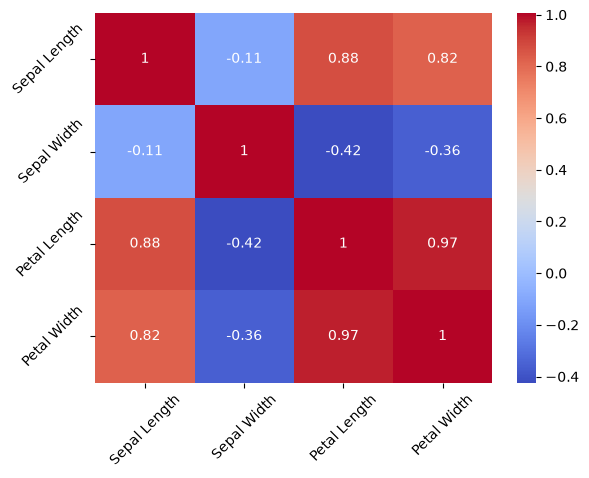

In [12]:
import seaborn as sns 

column_names = [
    "Sepal Length",
    "Sepal Width",
    "Petal Length",
    "Petal Width"
]

sns.heatmap(cov_matrix, annot = True, cmap = "coolwarm", xticklabels = column_names, yticklabels = column_names)

plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

### 6. Eigenvalues and Eigenvectors

In [58]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real
np.argsort(eigenvalues)
print("The eigen values are\n", eigenvalues,"\n")
print("The eigen vectors are\n", eigenvectors,"\n")

The eigen values are
 [2.93035378 0.92740362 0.14834223 0.02074601] 

The eigen vectors are
 [[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]] 



### 7. Explained Variance

In [14]:
eig_val_sum = np.sum(eigenvalues)
eig_val_percentage = np.round((eigenvalues/eig_val_sum)*100, 2)
print(*eig_val_percentage, sep = ", ")

4.026845637583896


### 8. Select Principal Components

In [41]:
principal_components = eigenvectors[:, [0,1]]
principal_components.shape

(4, 2)

In [42]:
print(principal_components)

[[ 0.52237162 -0.37231836]
 [-0.26335492 -0.92555649]
 [ 0.58125401 -0.02109478]
 [ 0.56561105 -0.06541577]]


### 9. Project 4D Data to 2D


In [55]:
project_data = X_standard @ principal_components 
project_data.shape

(150, 2)

### 10. Visualize PCA Result


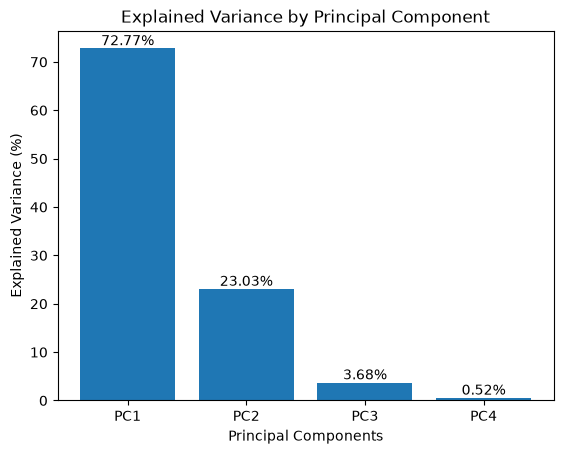

In [56]:
bars = plt.bar(["PC1", "PC2", "PC3", "PC4"], eig_val_percentage)

plt.bar_label(bars, fmt="%.2f%%")

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")

plt.show()

### 11. Validate with Scikit-learn

In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca_sklearn = pca.fit_transform(X_standard)

print("Explained variance ratio:")
print(np.round(pca.explained_variance_ratio_ * 100, 2))

print("Shape:")
print(X_pca_sklearn.shape)

Explained variance ratio:
[72.77 23.03]
Shape:
(150, 2)


### 12. Conclusion

##### The original data had 4 numerical features. PCA was implemented from scratch using standardisation, covariance matrix, eigen decomposition, and matrix projection. PC1 and PC2 explained 72.77% AND 23.03% respectively. Together these two contained approximately 95.8% of the total variance, allowing the dataset to be reduced to two dimensions from four while losing as less data as possible